In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape, plot_params_vs_mse
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, ['PERD', 'QGEN7']]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

**Validación por Retención (Tratamiento como Serie Temporal)**

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [4]:
random_model = ElectricSequentialRegressor(RandomForestRegressor(n_jobs=1, random_state=42), RandomForestRegressor(n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(10, 51),
    'estimator1__min_samples_split': randint(2, 21),
    'estimator1__max_features': uniform(0.1, 0.9),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(10, 51),
    'estimator2__min_samples_split': randint(2, 21),
    'estimator2__max_features': uniform(0.1, 0.9)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque...dom_state=42))
,param_distributions,"{'estimator1__max_depth': <scipy.stats....002AB60898510>, 'estimator1__max_features': <scipy.stats....002AB60899E50>, 'estimator1__min_samples_split': <scipy.stats....002AB60899790>, 'estimator1__n_estimators': <scipy.stats....002AB5DA9E950>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [6]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__max_features', 'param_estimator1__min_samples_split', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__max_features', 'param_estimator2__min_samples_split', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.2732129141933511


,param_estimator1__max_depth,param_estimator1__max_features,param_estimator1__min_samples_split,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__max_features,param_estimator2__min_samples_split,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,48,0.816889,16,90,30,0.240417,20,154,-0.328222,-0.656120,-0.000324
1,20,0.879559,5,53,12,0.118526,3,167,-0.421316,-0.842306,-0.000325
2,39,0.291105,2,87,31,0.106360,18,138,-0.417291,-0.834233,-0.000349
3,37,0.976380,16,91,12,0.873946,8,100,-0.342562,-0.684798,-0.000325
4,18,0.158546,5,89,23,0.827558,10,169,-0.287401,-0.574336,-0.000466
5,11,0.715810,16,89,16,0.648997,9,114,-0.287018,-0.573716,-0.000319
6,23,0.451955,19,33,11,0.482640,11,83,-0.378276,-0.756222,-0.000331
7,38,0.972626,13,63,19,0.905345,15,174,-0.298010,-0.595693,-0.000327
8,24,0.179643,9,82,33,0.421078,14,120,-0.300446,-0.600438,-0.000453
9,38,0.821977,2,100,18,0.795020,13,215,-0.289800,-0.579276,-0.000324


In [7]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])
evaluations

,PERD,QGEN7
MAE,0.494691,0.006523
MAPE,0.055860,0.006137
R2,0.948385,0.883008


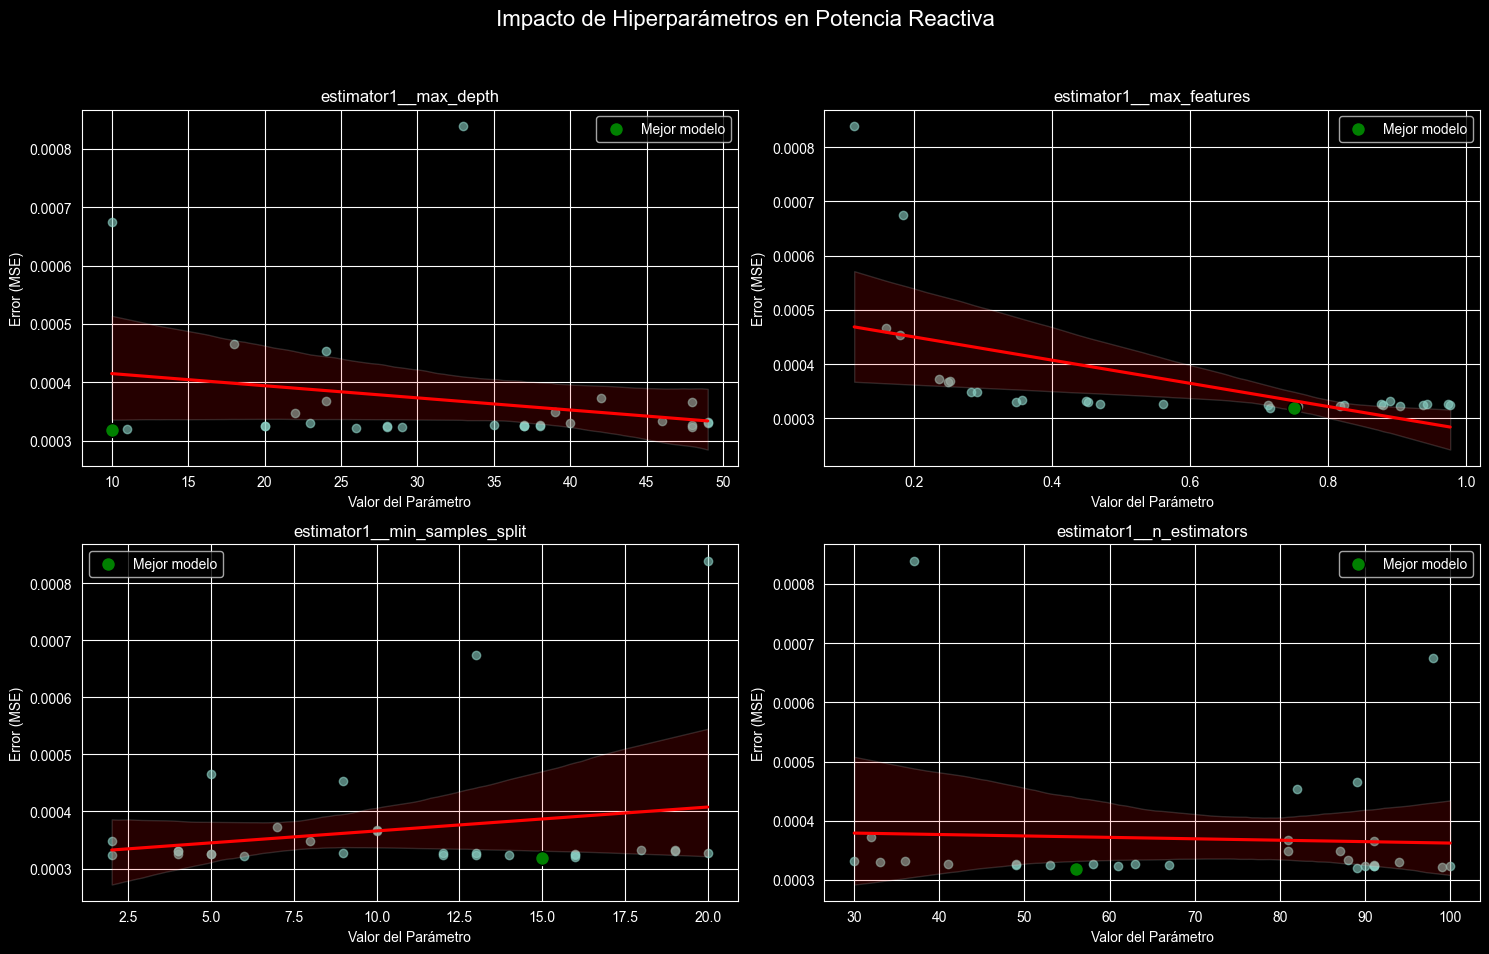

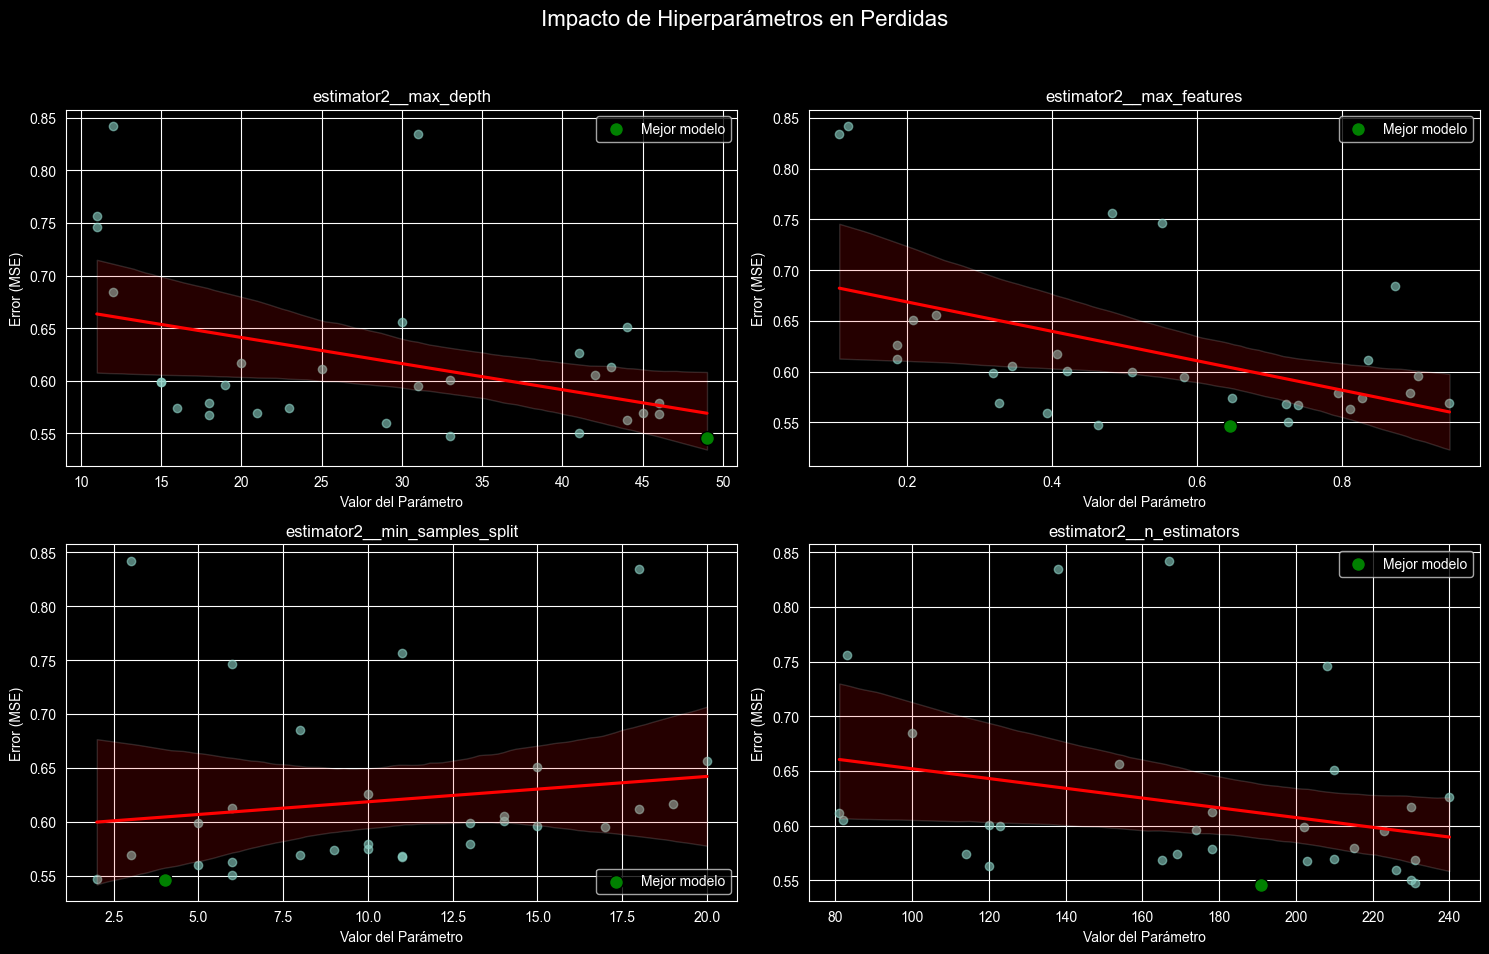

In [8]:
random_param_cols = [p for p in random_results if 'param_' in p]
plot_params_vs_mse(random_results, 'mean_test_mse_qgen7', 'estimator1', random_param_cols, 'Potencia Reactiva')
plot_params_vs_mse(random_results, 'mean_test_mse_perd', 'estimator2', random_param_cols, 'Perdidas')

<h2>Búsqueda Exhaustiva de Hiperparámetros</h2>

In [27]:
grid_model = ElectricSequentialRegressor(RandomForestRegressor(max_features=0.9, n_jobs=1, random_state=42), RandomForestRegressor(n_jobs=1, random_state=42))
grid = {
    'estimator1__n_estimators': [55, 80],
    'estimator1__max_depth': [10, 25],
    'estimator1__min_samples_split': [3, 15],
    'estimator2__n_estimators': [190, 250, 300],
    'estimator2__max_depth': [50, 75],
    'estimator2__min_samples_split': [3, 6],
    'estimator2__max_features': [0.7, 0.9]
}
grid_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
grid_search = GridSearchCV(grid_model, grid, scoring=grid_scoring, cv=TimeSeriesSplit(n_splits=3), n_jobs=-1, verbose=2, return_train_score=True, refit='mse_global')

In [28]:
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


,estimator,ElectricSeque...dom_state=42))
,param_grid,"{'estimator1__max_depth': [10, 25], 'estimator1__min_samples_split': [3, 15], 'estimator1__n_estimators': [55, 80], 'estimator2__max_depth': [50, 75], ...}"
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,80


In [30]:
best_grid_model = grid_search.best_estimator_
print('MSE: ' + str(grid_search.best_score_))
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.27081669572456696


,param_estimator1__max_depth,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,10,55,50,190,-0.272021,-0.543722,-0.000320
1,10,55,50,250,-0.271143,-0.541966,-0.000320
2,10,55,50,300,-0.270849,-0.541377,-0.000320
3,10,55,50,190,-0.274758,-0.549197,-0.000320
4,10,55,50,250,-0.273814,-0.547308,-0.000320
...,...,...,...,...,...,...,...
187,25,80,75,250,-0.275747,-0.551171,-0.000323
188,25,80,75,300,-0.275524,-0.550725,-0.000323
189,25,80,75,190,-0.278544,-0.556765,-0.000323
190,25,80,75,250,-0.277823,-0.555322,-0.000323


In [35]:
grid_predictions = best_grid_model.predict(x_test)
grid_MAE = mean_absolute_error(y_test, grid_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
grid_MAPE = mean_absolute_percentage_error(y_test + 1.0, grid_predictions + 1.0, multioutput='raw_values')
grid_R2 = r2_score(y_test, grid_predictions, multioutput='raw_values')
grid_data_score = np.vstack([grid_MAE, grid_MAPE, grid_R2])
pd.DataFrame(grid_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])

,PERD,QGEN7
MAE,0.493794,0.006438
MAPE,0.055749,0.006065
R2,0.948459,0.883681


In [ ]:
joblib.dump(best_grid_model, '../models/ESR_RandomForest.pkl')

**Validación Cruzada Final para Contrastación de Resultados**

In [10]:
evaluate_model = ElectricSequentialRegressor(RandomForestRegressor(max_depth=10, min_samples_split=3, n_estimators=80, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=50, max_features=0.7, min_samples_split=3, n_estimators=300, n_jobs=1, random_state=42))
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.2793152859585237
MAE: 0.26462250338788473
MAPE: 0.03267885042612446
R2: 0.9190443328274892


In [13]:
evaluate_model = joblib.load('../models/ESR_RandomForest.pkl')
evaluate_model.fit(x_train, y_train)
evaluate_predictions = evaluate_model.predict(x_test)

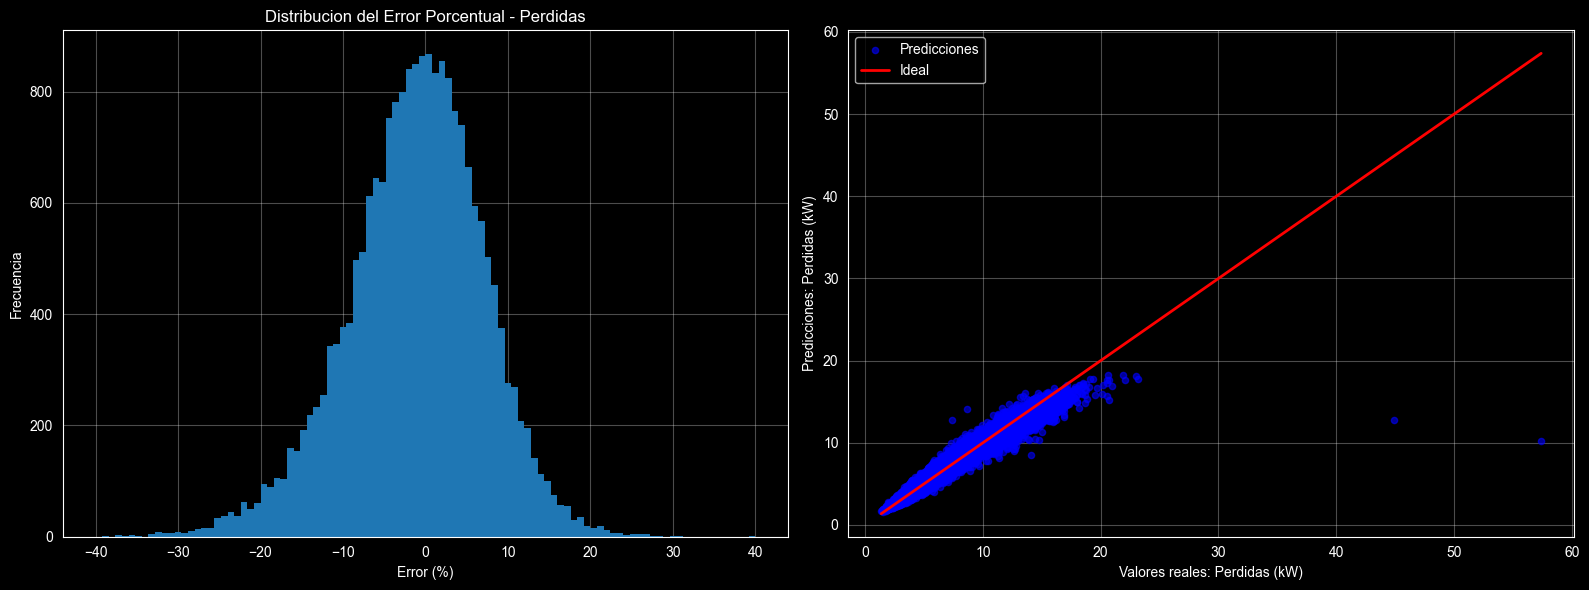

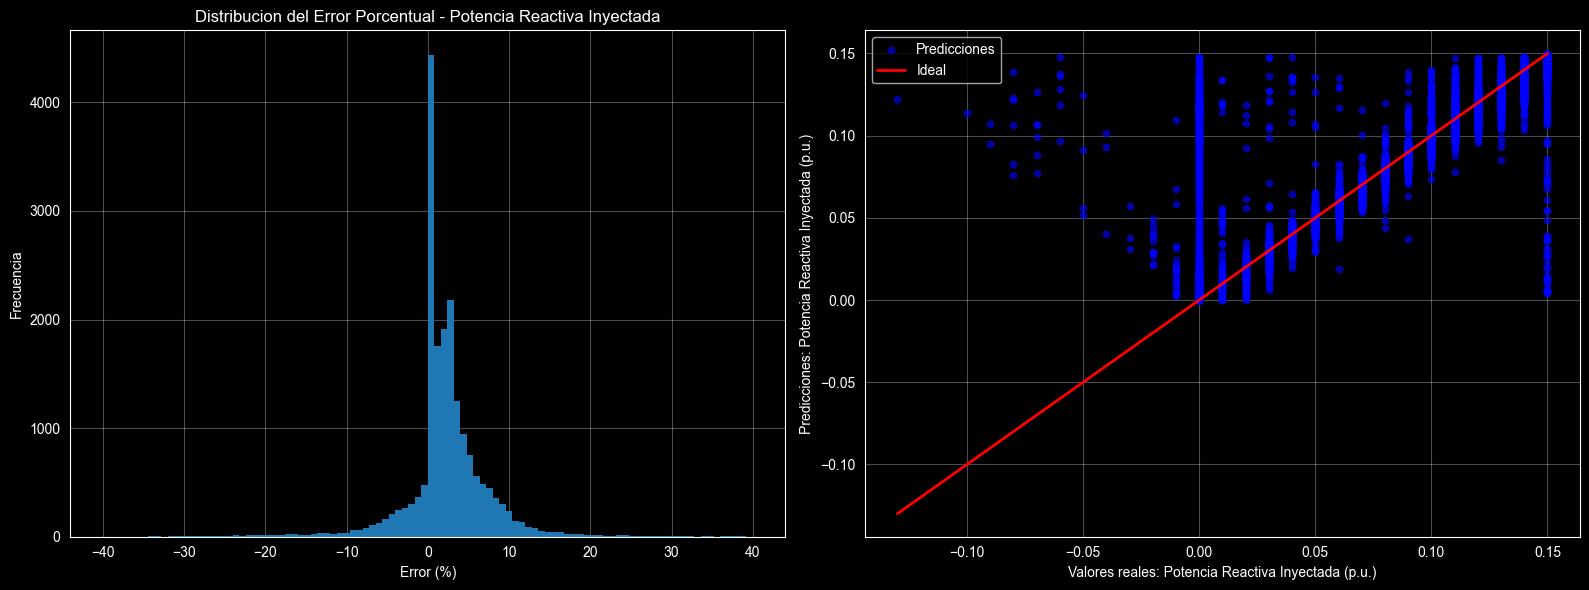

In [14]:
plot_performance_analysis(
    y_test['PERD'],
    evaluate_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/RandomForest/ESR_RandomForest_Perd.png'
)

plot_performance_analysis(
    y_test['QGEN7'],
    evaluate_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_RandomForest_QGEn.png'
)